# 1. Introdução

# Conclusões e Insights de Negócio
## Projeto: Credit Risk – Home Credit Default Risk
Este notebook apresenta a consolidação dos resultados obtidos ao longo do projeto, reunindo os principais aprendizados da análise exploratória, engenharia de variáveis, modelagem e otimização dos modelos.

O objetivo é transformar os resultados técnicos em conclusões interpretáveis e insights relevantes para o contexto de risco de crédito.

# Bibliotecas

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# 2. Resumo Executivo
O projeto teve como objetivo desenvolver um modelo capaz de identificar clientes com maior probabilidade de inadimplência, utilizando informações financeiras, demográficas e comportamentais disponibilizadas pela base Home Credit Default Risk.

Ao longo do projeto foram aplicadas técnicas de análise exploratória, engenharia de variáveis, modelagem supervisionada e otimização de hiperparâmetros.

O melhor desempenho foi obtido pelo algoritmo XGBoost, que apresentou elevada capacidade de separação entre clientes adimplentes e inadimplentes, além de desempenho consistente após ajuste do threshold de classificação.


# 3. Principais Descobertas da EDA


## 3.1 Variável Target
A variável target apresentou forte desbalanceamento entre as classes, com aproximadamente 92% de clientes adimplentes e 8% de clientes inadimplentes.

Esse comportamento impactou diretamente a escolha das métricas de avaliação e as estratégias utilizadas durante a modelagem.

## 3.2 Missing Values
Foi identificado elevado volume de valores ausentes em diversas variáveis.

Grande parte dessas ausências estava associada à não aplicabilidade das informações ao perfil dos clientes, indicando potencial informativo da ausência dos dados. 

## 3.3 Variáveis Numéricas
As variáveis financeiras apresentaram assimetria positiva, caudas longas e presença de outliers, comportamento esperado em bases relacionadas a crédito e renda.

## 3.4 Variáveis Categóricas
Diferenças relevantes foram observadas entre categorias relacionadas a escolaridade, renda e perfil dos clientes, sugerindo potencial para segmentação de risco.

# 4. Impacto da Egenharia de Variáveis

## 4.1 Tratamento de Missing

A criação de flags de ausência permitiu capturar informação associada a variáveis não preenchidas, contribuindo positivamente para o modelo.

## 4.2 Transformações Numéricas
Transformações logarítmicas foram aplicadas em variáveis financeiras com forte assimetria, reduzindo o impacto dos outliers e melhorando a estrutura dos dados para modelagem.

## 4.3 Feature Creation

Novas variáveis derivadas foram criadas para representar relações financeiras entre os clientes, como razão entre crédito e valor do bem financiado.

Parte dessas variáveis apareceu entre os atributos mais relevantes identificados pelo modelo final. 

# 5. Evolução dos Modelos

Ao longo do processo observou-se evolução gradual da capacidade de identificação dos inadimplentes.

A principal melhoria foi obtida pela combinação entre XGBoost e ajuste de threshold, alcançando aproximadamente 74% de recall para a classe inadimplente.

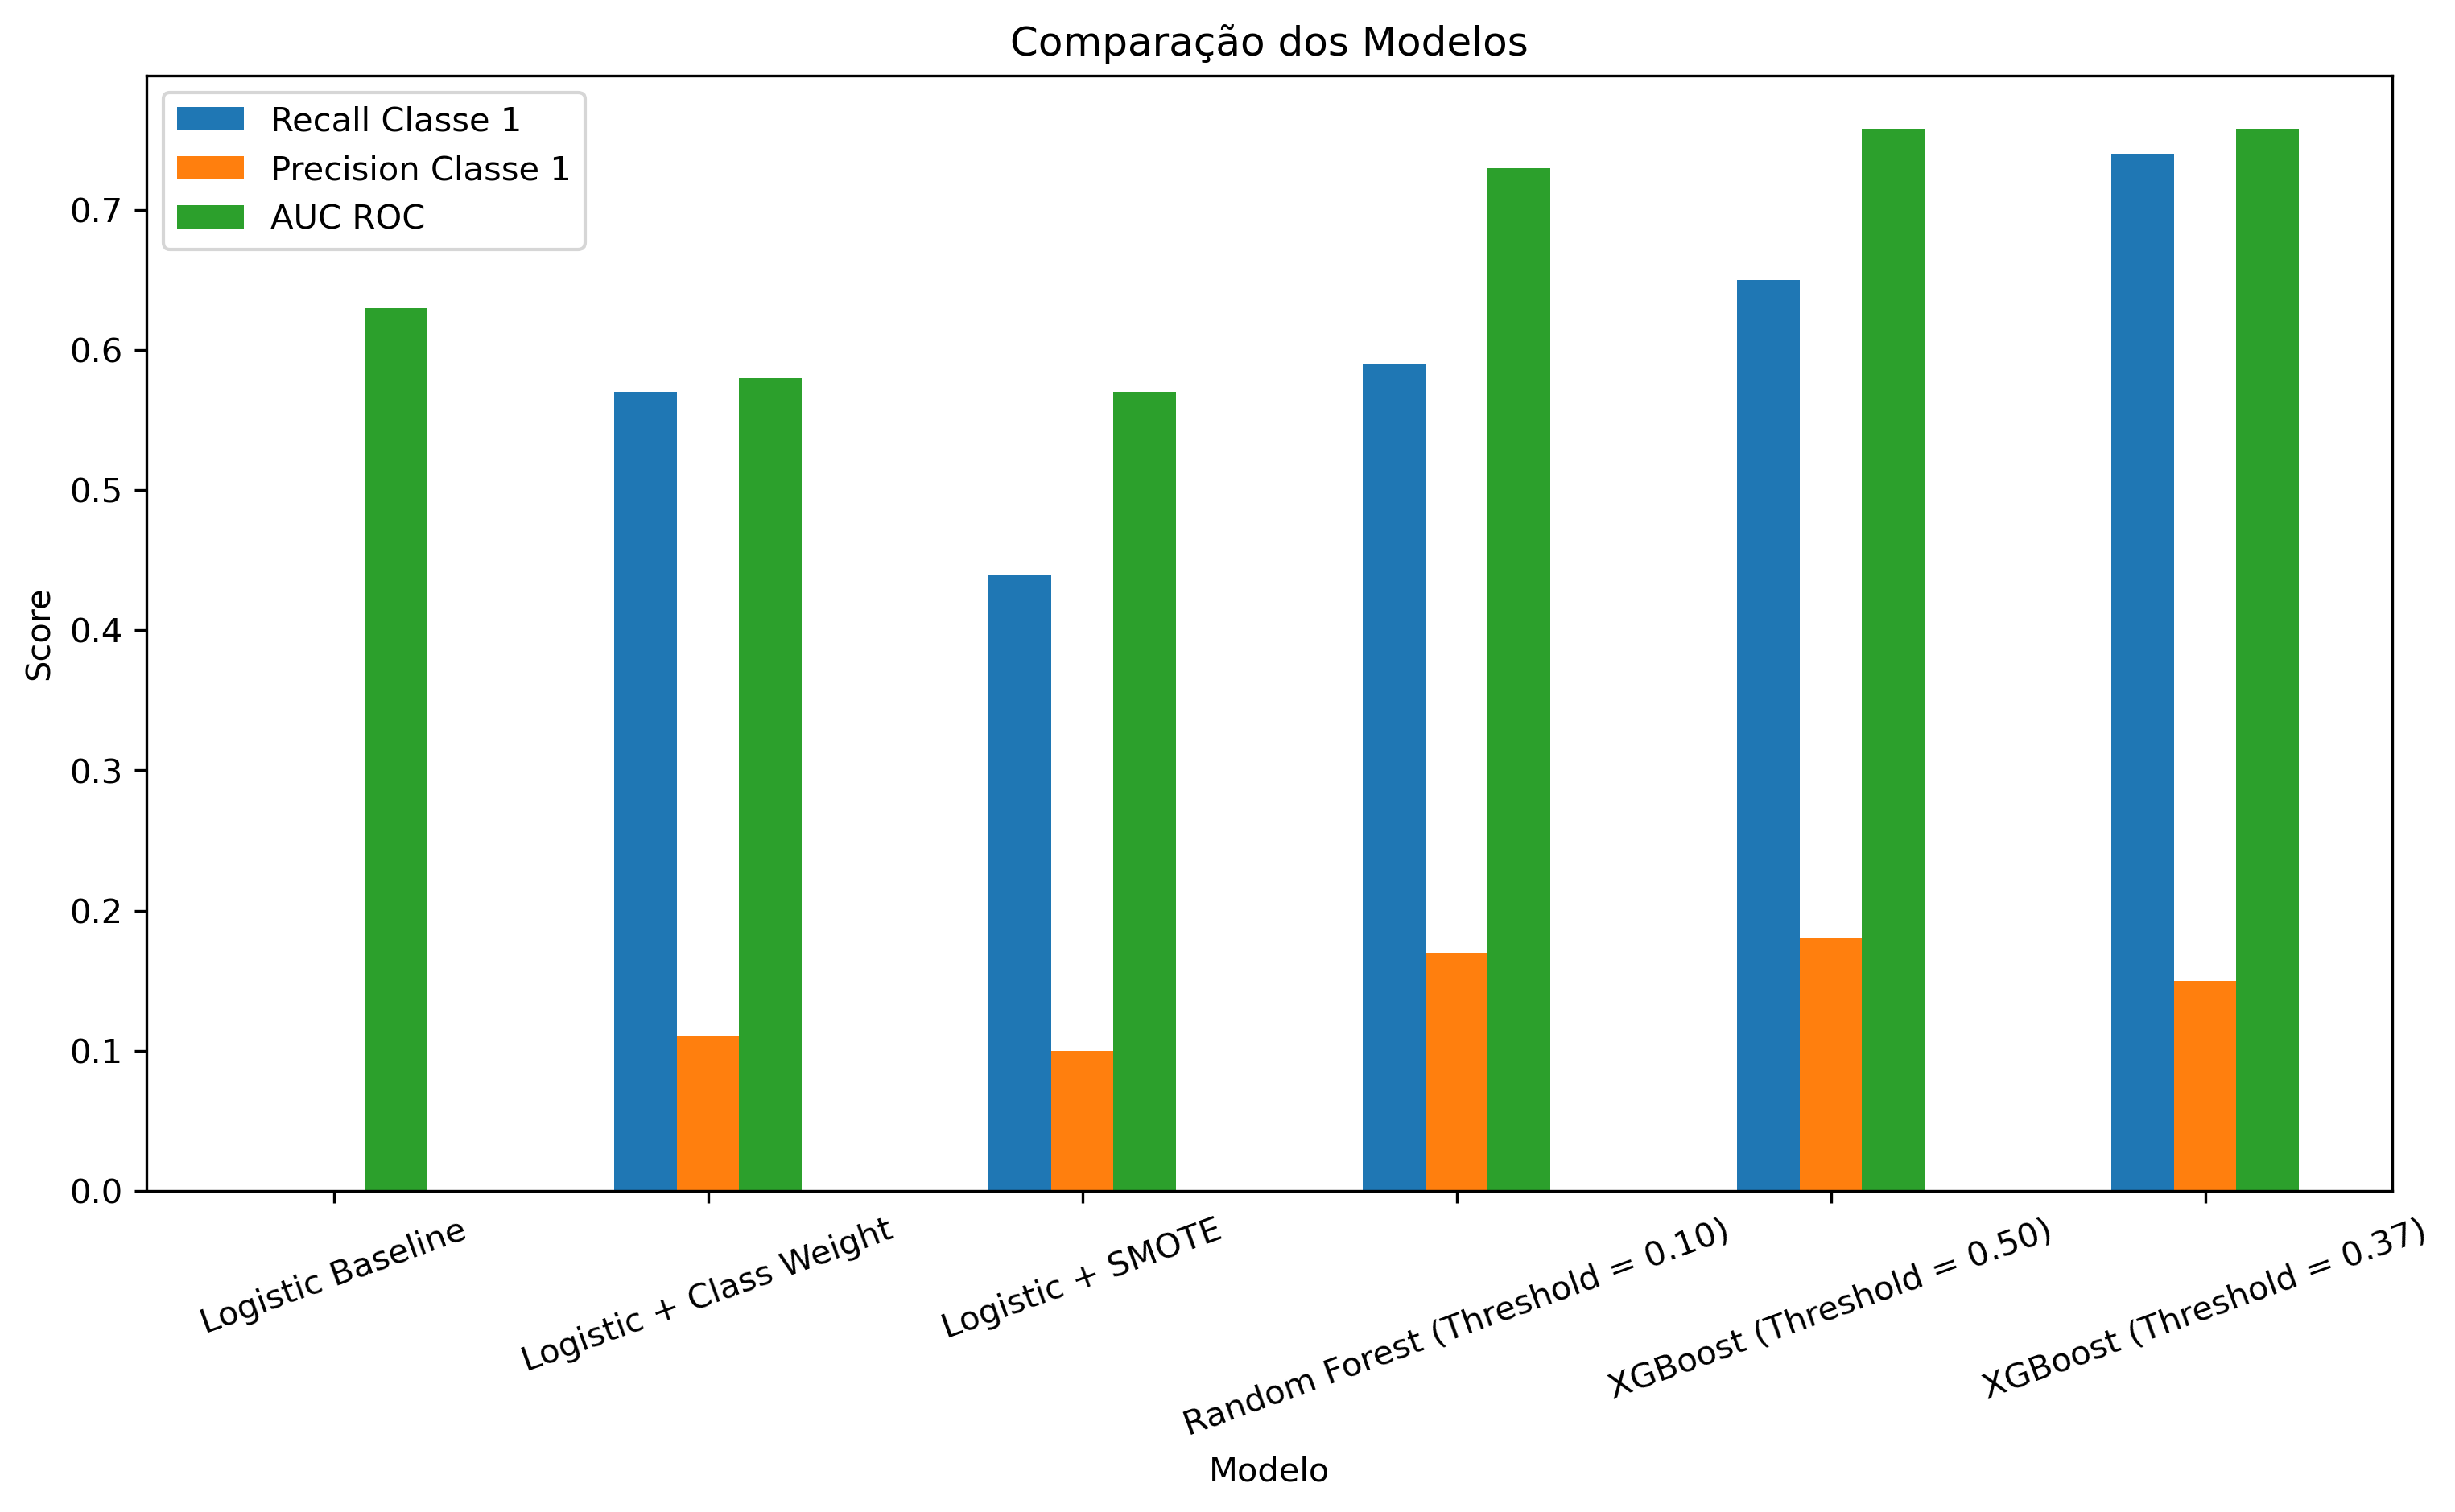

In [7]:
display(Image('../data/processed/compracao_modelos.png'))

## Interpretação da Evolução dos Modelos

A comparação dos modelos evidencia o impacto significativo que o tratamento do desbalanceamento e a escolha do algoritmo exercem sobre a capacidade de identificação dos clientes inadimplentes.

O modelo baseline, apesar de apresentar elevada acurácia, demonstrou baixa utilidade prática para o problema de crédito, uma vez que classificava praticamente todas as observações como adimplentes, falhando na identificação da classe inadimplente.

A introdução da estratégia de balanceamento com class_weight='balanced' promoveu aumento expressivo do recall da classe inadimplente, demonstrando que o desbalanceamento da variável target exercia forte influência sobre o processo de aprendizagem dos modelos.

A utilização do SMOTE não apresentou ganhos relevantes neste contexto, resultando em desempenho inferior em relação ao balanceamento por ponderação das classes.

A Random Forest demonstrou elevada capacidade de separação entre as classes, evidenciada pelo aumento do AUC-ROC, porém seu potencial somente foi aproveitado após o ajuste do threshold de classificação, reforçando que a escolha do limiar de decisão pode ser tão importante quanto o algoritmo utilizado.

Por fim, o XGBoost apresentou o melhor desempenho geral entre todos os modelos avaliados. A combinação entre sua elevada capacidade de separação das classes e o ajuste do threshold permitiu atingir aproximadamente 74% de recall para a classe inadimplente, tornando-o o modelo mais adequado para o contexto do projeto.

# 6. Variáveis Mais Importantes

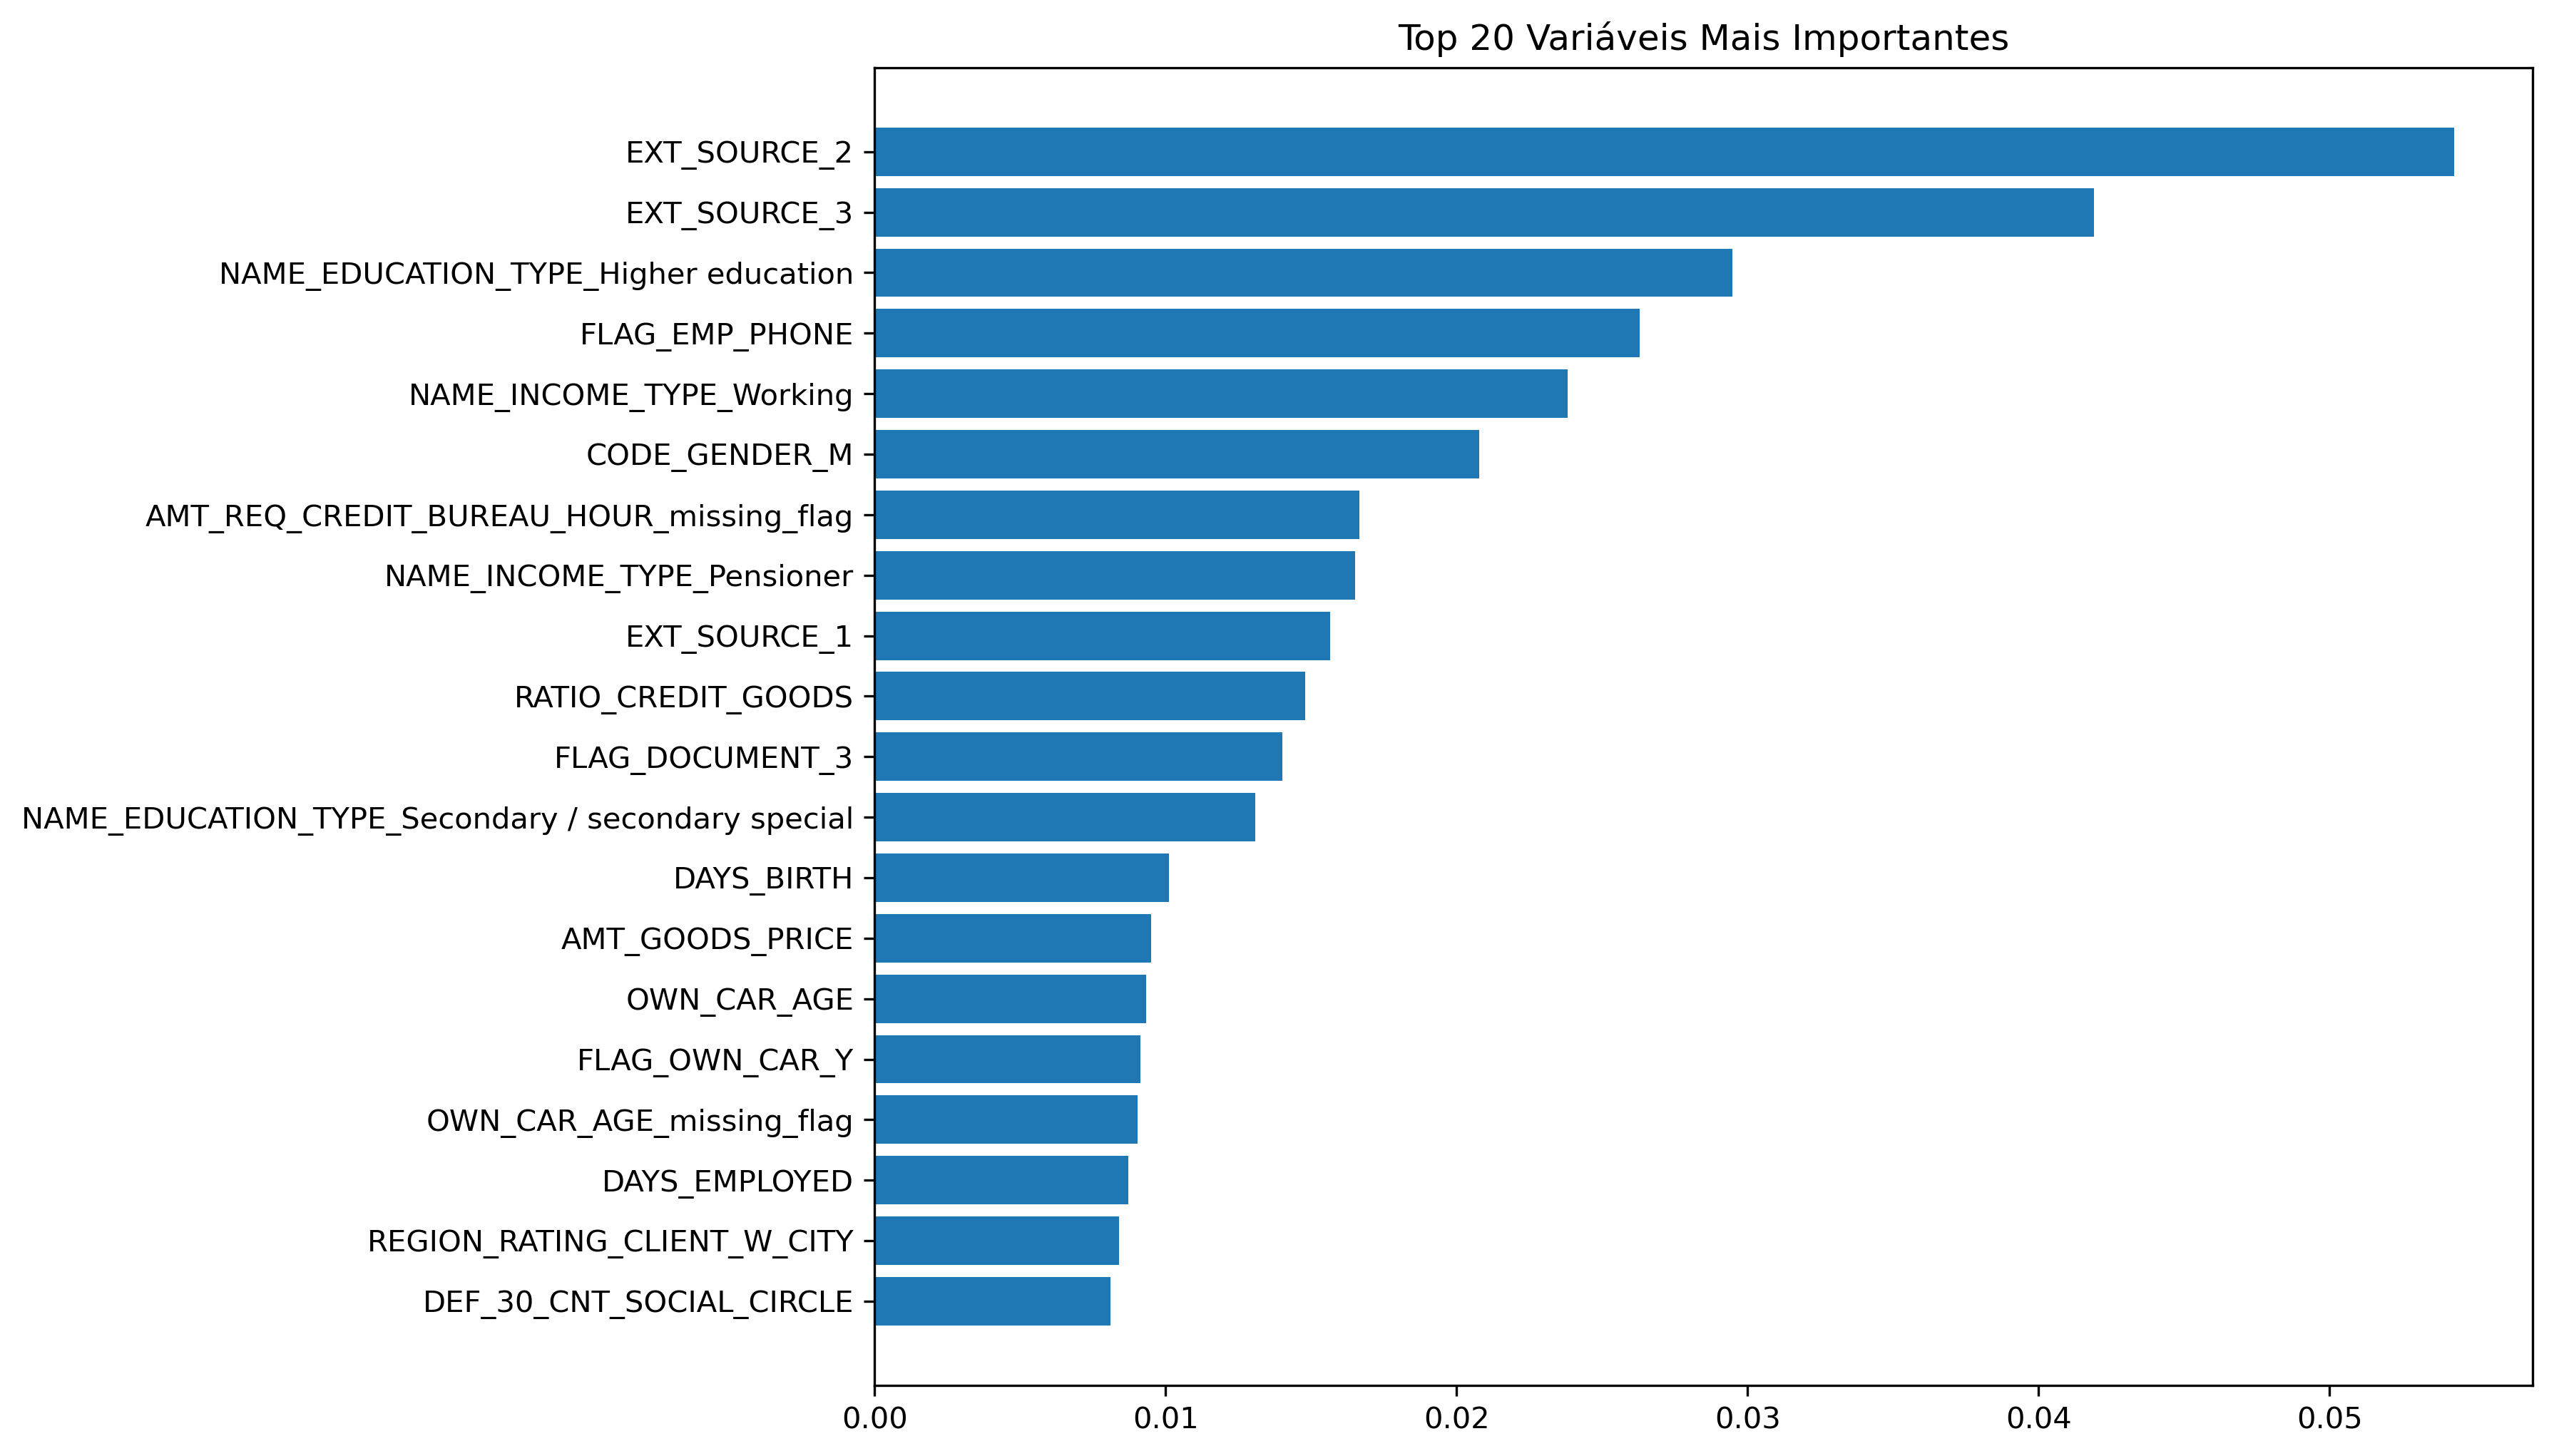

In [8]:
display(Image('../data/processed/top20_features.png'))

## Interpretação das Variáveis Mais Importantes

A análise da importância das variáveis mostra que os principais fatores associados ao risco de inadimplência estão relacionados ao histórico e à qualidade de crédito dos clientes.

Os indicadores externos de crédito (EXT_SOURCE_2 e EXT_SOURCE_3) apresentaram as maiores contribuições para o modelo, sugerindo que informações relacionadas ao comportamento financeiro e ao histórico de crédito possuem elevado poder preditivo na identificação de clientes inadimplentes.

Além dos indicadores externos, características socioeconômicas como idade, escolaridade e tipo de renda também exerceram influência relevante sobre as previsões realizadas pelo modelo, indicando que aspectos demográficos e de perfil econômico contribuem para a segmentação do risco.

Variáveis relacionadas à exposição ao crédito e à capacidade de pagamento também figuraram entre as mais importantes, reforçando a relevância da relação entre renda, valor financiado e comprometimento financeiro na análise de crédito.

Destaca-se ainda a presença de variáveis derivadas e indicadores criados durante a etapa de engenharia de features, como a variável RATIO_CREDIT_GOODS e flags de ausência de dados. Esse resultado demonstra que o processo de engenharia de variáveis agregou informação relevante ao modelo e contribuiu para sua capacidade de discriminação.

Os resultados obtidos reforçam que o risco de inadimplência é resultado da combinação de múltiplos fatores financeiros, demográficos e comportamentais, não sendo explicado por uma única característica isolada.

# 7. Insights de negócio

A análise realizada ao longo do projeto permitiu identificar padrões relevantes associados ao risco de inadimplência, fornecendo informações que podem apoiar decisões relacionadas à concessão e gestão de crédito.

## 7.1 Qualidade do Histórico de Crédito
Os indicadores externos de crédito apresentaram a maior influência sobre as previsões do modelo, demonstrando que informações relacionadas ao histórico financeiro dos clientes possuem elevado poder de identificação do risco de inadimplência.

Esse resultado sugere que o comportamento financeiro passado continua sendo um dos principais fatores para avaliação da probabilidade de inadimplência futura.

## 7.2 Capacidade de Pagamento
Os resultados indicam que a relação entre renda, valor do crédito e valor do bem financiado possui maior relevância para avaliação do risco do que os valores isolados dessas variáveis.

Esse comportamento reforça a importância de avaliar o comprometimento da capacidade financeira dos clientes, e não apenas sua renda ou o valor solicitado no financiamento.

## 7.3 Perfil Socioeconômico
Variáveis relacionadas à escolaridade, idade e tipo de renda figuraram entre os atributos mais relevantes para o modelo.

Esse resultado sugere que diferentes perfis socioeconômicos apresentam comportamentos distintos de risco, possibilitando estratégias mais segmentadas de avaliação de crédito.

## 7.4 Informação Presente na Ausência dos Dados
Indicadores criados para representar valores ausentes apareceram entre as variáveis importantes para o modelo.

Esse comportamento demonstra que a ausência de determinadas informações pode carregar sinal relevante para avaliação do risco dos clientes e não deve ser tratada apenas como um problema de qualidade dos dados.

## 7.5 Valor da Engenharia de Variáveis
Variáveis criadas durante a etapa de engenharia de features figuraram entre as variáveis mais relevantes do modelo final.

Esse resultado demonstra que a criação de novas representações dos dados, principalmente relacionadas à exposição ao crédito e à capacidade de pagamento, contribuiu para melhorar a capacidade preditiva do sistema.

## 7.6 Importância do Ajuste da Estratégia de Classificação
Os resultados obtidos demonstraram que o desempenho do modelo foi fortemente impactado pelo tratamento do desbalanceamento da variável target e pela definição adequada do threshold de classificação.

Ajustes nesse processo proporcionaram ganhos mais relevantes do que a simples troca entre alguns algoritmos de Machine Learning, reforçando a importância da compreensão do problema de negócio e das métricas utilizadas. ``

## 7.7 Apoio à Tomada de Decisão
O modelo final foi capaz de identificar aproximadamente 74% dos clientes inadimplentes presentes na base de teste.

Embora o modelo não substitua a análise de crédito tradicional, seus resultados indicam potencial para utilização como ferramenta de apoio, permitindo priorizar clientes de maior risco e direcionar análises mais aprofundadas para casos específicos.

# 8. Limitações do Projeto

Apesar dos resultados positivos obtidos ao longo do desenvolvimento do projeto, algumas limitações devem ser consideradas na interpretação dos resultados e no potencial uso do modelo em um ambiente real.

## Escopo dos Dados Utilizados
O projeto foi desenvolvido utilizando exclusivamente a base principal application_train, não incorporando tabelas auxiliares disponibilizadas na competição, como histórico de crédito, pagamentos anteriores e informações de relacionamento financeiro dos clientes.

A utilização dessas bases adicionais pode fornecer informações complementares e potencialmente aumentar a capacidade preditiva do modelo.

## Dados Históricos Estáticos
As análises foram realizadas com base em um retrato estático dos clientes no momento da solicitação do crédito. Dessa forma, o modelo não considera mudanças de comportamento financeiro ao longo do tempo ou eventos posteriores à coleta dos dados.

## Desbalanceamento da Variável Target
Embora tenham sido aplicadas estratégias específicas para lidar com o forte desbalanceamento entre as classes, a identificação de clientes inadimplentes continua sendo um desafio inerente ao problema.

Esse comportamento impacta diretamente o equilíbrio entre Recall e Precision, exigindo decisões alinhadas aos objetivos de negócio.

## Otimização de Hiperparâmetros
O processo de otimização foi limitado aos intervalos de hiperparâmetros definidos durante o projeto. A exploração de espaços de busca maiores ou o uso de estratégias mais sofisticadas de otimização pode resultar em melhorias adicionais de desempenho.

## Interpretação e Aplicação do Modelo
O modelo foi desenvolvido com finalidade educacional e de portfólio, não tendo sido submetido a etapas de validação regulatória, monitoramento produtivo, testes de estabilidade temporal ou análise de impacto financeiro real.

Sua utilização em ambiente operacional exigiria etapas adicionais de validação, governança e monitoramento contínuo.

# 9. Conclusão Final

Limitações do Projeto
Apesar dos resultados positivos obtidos ao longo do desenvolvimento do projeto, algumas limitações devem ser consideradas na interpretação dos resultados e no potencial uso do modelo em um ambiente real.

Escopo dos Dados Utilizados
O projeto foi desenvolvido utilizando exclusivamente a base principal application_train, não incorporando tabelas auxiliares disponibilizadas na competição, como histórico de crédito, pagamentos anteriores e informações de relacionamento financeiro dos clientes.

A utilização dessas bases adicionais pode fornecer informações complementares e potencialmente aumentar a capacidade preditiva do modelo.

Dados Históricos Estáticos
As análises foram realizadas com base em um retrato estático dos clientes no momento da solicitação do crédito. Dessa forma, o modelo não considera mudanças de comportamento financeiro ao longo do tempo ou eventos posteriores à coleta dos dados.

Desbalanceamento da Variável Target
Embora tenham sido aplicadas estratégias específicas para lidar com o forte desbalanceamento entre as classes, a identificação de clientes inadimplentes continua sendo um desafio inerente ao problema.

Esse comportamento impacta diretamente o equilíbrio entre Recall e Precision, exigindo decisões alinhadas aos objetivos de negócio.

Otimização de Hiperparâmetros
O processo de otimização foi limitado aos intervalos de hiperparâmetros definidos durante o projeto. A exploração de espaços de busca maiores ou o uso de estratégias mais sofisticadas de otimização pode resultar em melhorias adicionais de desempenho.

Interpretação e Aplicação do Modelo
O modelo foi desenvolvido com finalidade educacional e de portfólio, não tendo sido submetido a etapas de validação regulatória, monitoramento produtivo, testes de estabilidade temporal ou análise de impacto financeiro real.

Sua utilização em ambiente operacional exigiria etapas adicionais de validação, governança e monitoramento contínuo.